### Import

In [1]:
import utils as ut

### Parameters

In [2]:
target_column = "AMZN"
input_days= 30
output_days= [1, 7, 14]
test_size=0.2
shuffle=True

### Load dataset

In [3]:
data = ut.read_and_clean_data(file_path = "./dataset/portfolio_data.csv", drop_list = ["DPZ", "BTC", "NFLX"])

Loading the data...
Data shape: (1520, 2)
Null values: Date    0
AMZN    0
dtype: int64
Duplicate rows: 0
Converting Date column to datetime...
Load data completed.


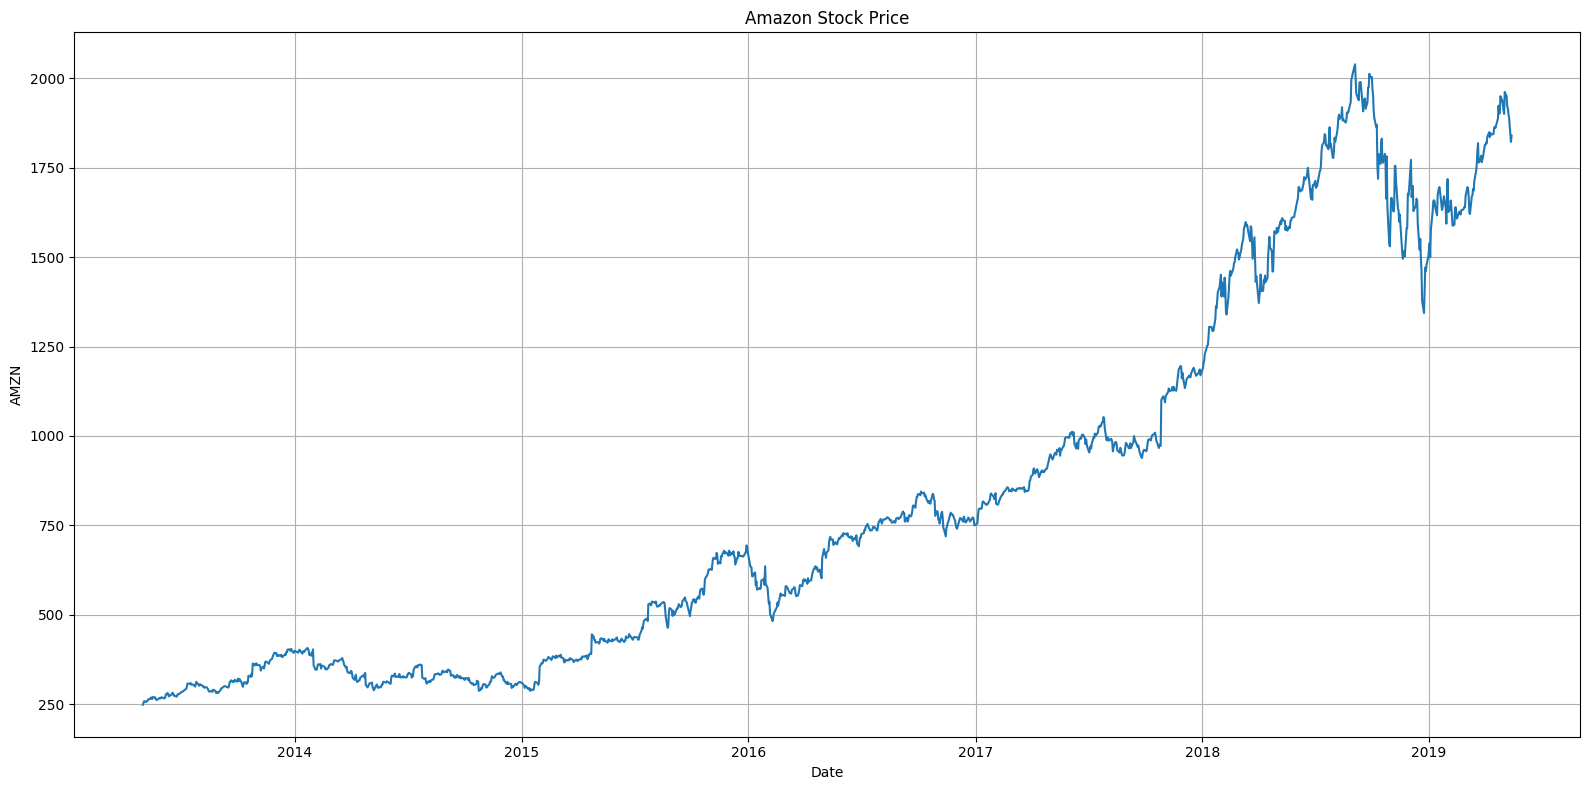

In [4]:
ut.plot_data(data, "Amazon Stock Price", "Date", "AMZN")

### Generate Sliding Windows

In [5]:
selected_value = data[target_column].values
window_data = {}
for days in output_days:
    X, y = ut.generate_sliding_windows(
        selected_value,
        input_days,
        days
        )
    window_data[days] = {
        "X" : X,
        "y" : y
    }

Input : 30 days | Output : 1 days | Windows: 1490
Input : 30 days | Output : 7 days | Windows: 1484
Input : 30 days | Output : 14 days | Windows: 1477


### Split Data

In [6]:
train_test_data = ut.split_data(
    window_data,
    output_days,
    test_size,
    shuffle
)

### Data Scaling

In [7]:
scaled_data = ut.scale_all_data(train_test_data)

### Train Regression Models

In [8]:
models_list = list(ut.AcceptableModelNames)

trained_models = ut.train_all_models(
    models_list,
    output_days,
    scaled_data
)


Training LR...
LR training completed.

Training KNN...
KNN training completed.

Training DT...
DT training completed.

Training RF...
RF training completed.

Training MLP...
MLP training completed.


### Regression Model Predictions

In [9]:
predictions = ut.predict_all_models(
    models_list,
    trained_models,
    output_days,
    scaled_data
)

### Inverse Predictions

In [10]:
predictions_real = ut.inverse_transform_all_predictions(
    models_list,
    predictions,
    output_days,
    scaled_data
)

### Inverse Actual Values

In [11]:
y_test_real = ut.inverse_transform_y_test(
    output_days,
    scaled_data
)

### Evaluation Models

In [12]:
evaluate_results = ut.evaluate_all_models(
    predictions_real,
    output_days,
    y_test_real
)

### Evaluation Plot Models

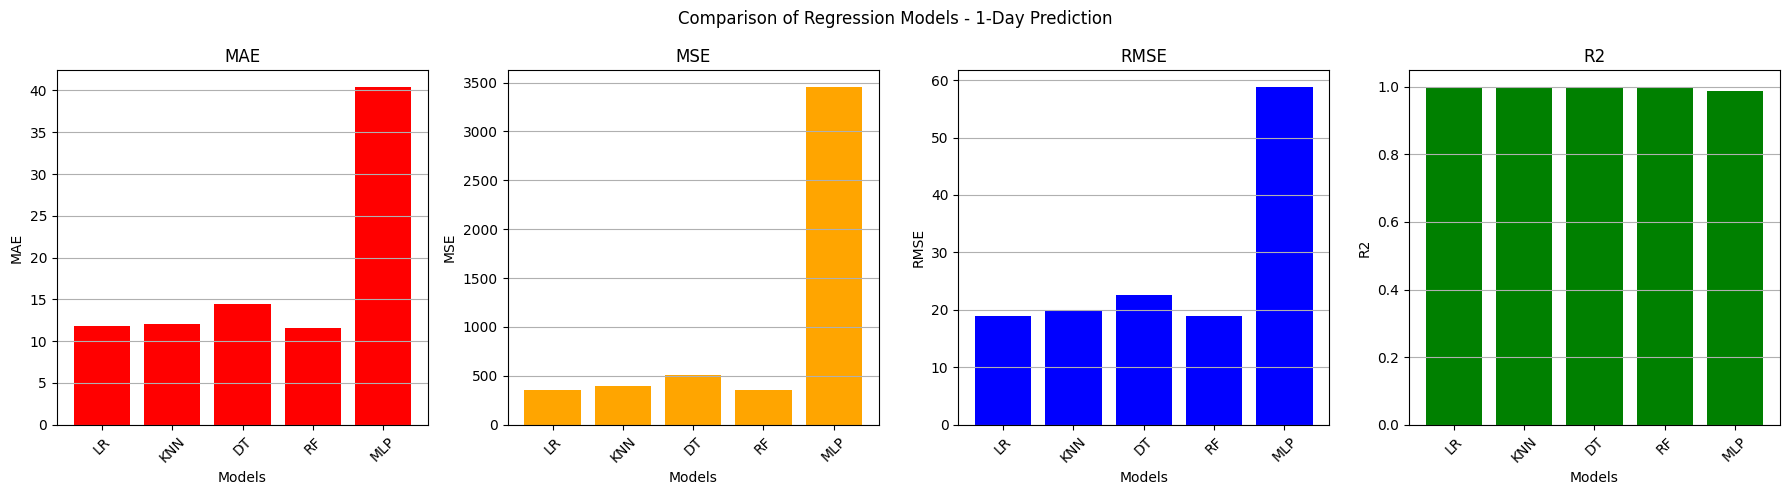

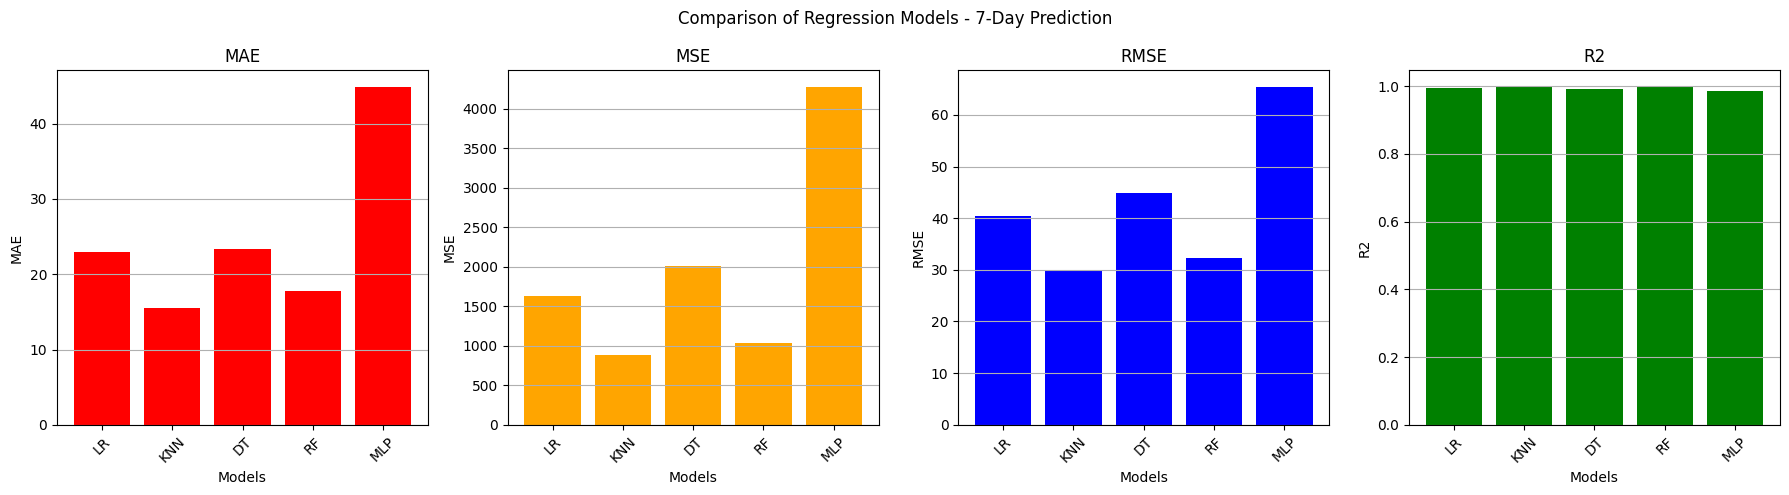

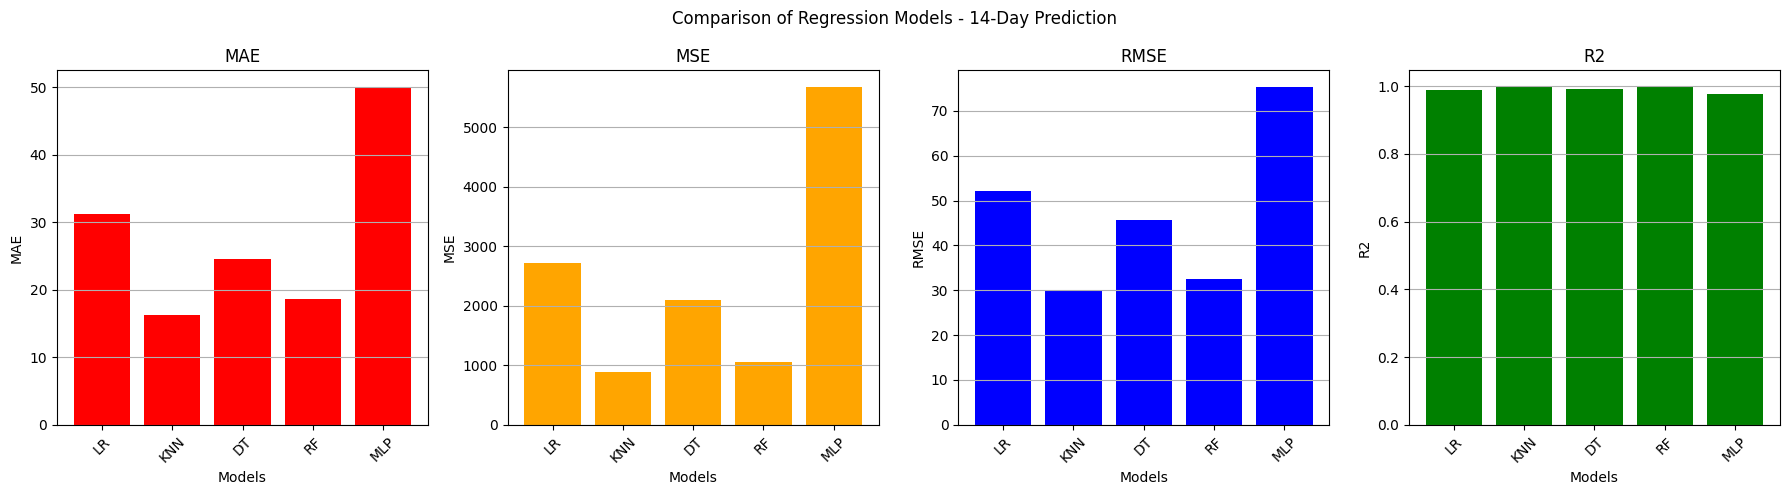

In [13]:
for day in output_days:
    ut.plot_model_evaluation(
        evaluate_results[day],
        day
    )

### Save

In [14]:
for day in output_days:
    ut.save_results_json(
        evaluate_results[day],
        f"results_{day}day.json"
    )

Results saved successfully: results_1day.json
Results saved successfully: results_7day.json
Results saved successfully: results_14day.json
